# 08 Markov Recommendation Eval
Этап 14: Markov-1 recommendation evaluation с переиспользованием готовых артефактов проекта.

## 1) Imports

In [1]:
import json

import numpy as np
import pandas as pd

from _shared_notebook_utils import RESEARCH_CHECKPOINT_DIR, ROOT

ARTIFACTS_DIR = ROOT / "artifacts"
RESULTS_DIR = ARTIFACTS_DIR / "results"

print("ROOT =", ROOT)
print("RESEARCH_CHECKPOINT_DIR =", RESEARCH_CHECKPOINT_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

ROOT = C:\Users\Dmitry\code-projects\diploma-crop-rotation
RESEARCH_CHECKPOINT_DIR = C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\research_checkpoint
RESULTS_DIR = C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results


## 2) Resolve known artifacts
Используем фиксированные пути артефактов из текущего пайплайна (03, 07) без широкого сканирования файловой системы.

In [2]:
baseline_dir = RESEARCH_CHECKPOINT_DIR / "baseline"
train_path = baseline_dir / "train_df.pkl"
val_path = baseline_dir / "val_df.pkl"
test_path = baseline_dir / "test_df.pkl"

recommendation_dir = RESULTS_DIR / "recommendation"
catboost_metric_files = sorted(recommendation_dir.glob("recommendation_metrics_*.csv")) if recommendation_dir.exists() else []

known_artifacts = [train_path, val_path, test_path] + catboost_metric_files
artifact_status_df = pd.DataFrame([
    {
        "path": p.relative_to(ROOT).as_posix() if p.exists() else p.relative_to(ROOT).as_posix(),
        "exists": p.exists(),
        "size_mb": round(p.stat().st_size / (1024 ** 2), 3) if p.exists() else np.nan,
    }
    for p in known_artifacts
])

print("Known artifacts (from pipeline contracts):")
display(artifact_status_df)

Known artifacts (from pipeline contracts):


,path,exists,size_mb
0,artifacts/research_checkpoint/baseline/train_d...,True,3190.161
1,artifacts/research_checkpoint/baseline/val_df.pkl,True,683.588
2,artifacts/research_checkpoint/baseline/test_df...,True,683.627
3,artifacts/results/recommendation/recommendatio...,True,0.000


## 3) Load available project files
Загружаем frozen split и считаем transition matrix строго из train_df (parity с notebook 03).

In [3]:
for needed in [train_path, val_path, test_path]:
    if not needed.exists():
        raise FileNotFoundError(f"Required file not found: {needed}. Run notebook 03 first.")

train_df = pd.read_pickle(train_path)
val_df = pd.read_pickle(val_path)
test_df = pd.read_pickle(test_path)

# Strict parity with notebook 03: train-only transition table P(target | history_3)
transition_counts = (
    train_df.groupby(["history_3", "target"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
    .dropna(subset=["history_3", "target"])
    .astype({"history_3": "string", "target": "string"})
)
transition_prob_matrix = (
    transition_counts.pivot(index="history_3", columns="target", values="count")
    .fillna(0.0)
)
transition_prob_matrix = transition_prob_matrix.div(
    transition_prob_matrix.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)
transition_source = "computed_from_train_df_nb03_parity"
used_transition_fallback = False

catboost_metrics_tables = []
for p in catboost_metric_files:
    df_m = pd.read_csv(p)
    df_m["source_file"] = p.name
    catboost_metrics_tables.append(df_m)
catboost_metrics_df = pd.concat(catboost_metrics_tables, ignore_index=True) if catboost_metrics_tables else pd.DataFrame()

print("Loaded split shapes: train/val/test =", train_df.shape, val_df.shape, test_df.shape)
print("transition_source =", transition_source)
print("transition shape =", transition_prob_matrix.shape)
print("catboost metrics files found =", len(catboost_metric_files))

Loaded split shapes: train/val/test = (26957630, 12) (5776566, 12) (5777014, 12)
transition_source = computed_from_train_df_nb03_parity
transition shape = (18, 9)
catboost metrics files found = 1


## 4) Validate required data
Проверяем обязательные колонки и согласуем пространство классов между split и transition matrix.

In [4]:
required_cols = {"history_3", "target"}
for split_name, split_df in [("validation", val_df), ("test", test_df), ("train", train_df)]:
    missing = sorted(required_cols - set(split_df.columns))
    if missing:
        raise ValueError(f"Missing required columns in {split_name}: {missing}")

for split_df in [train_df, val_df, test_df]:
    split_df["history_3"] = split_df["history_3"].astype("string")
    split_df["target"] = split_df["target"].astype("string")

train_classes = train_df["target"].dropna().astype(str).unique().tolist()
val_classes = val_df["target"].dropna().astype(str).unique().tolist()
test_classes = test_df["target"].dropna().astype(str).unique().tolist()
matrix_cols = [str(c) for c in transition_prob_matrix.columns.tolist()]

# Deterministic class order improves reproducibility for top-k extraction under ties.
class_names = sorted(set(matrix_cols + train_classes + val_classes + test_classes))
if not class_names:
    raise ValueError("No classes detected for Markov evaluation.")

transition_prob_matrix.index = transition_prob_matrix.index.map(str)
transition_prob_matrix.columns = transition_prob_matrix.columns.map(str)
transition_prob_matrix = transition_prob_matrix.reindex(index=class_names, columns=class_names, fill_value=0.0)

print("n_classes =", len(class_names))
print("transition reindexed shape =", transition_prob_matrix.shape)

n_classes = 9
transition reindexed shape = (9, 9)


## 5) Build Markov recommendation outputs
Формируем top-k рекомендации из P(target | history_3) с явным fallback на глобальное распределение train target.

In [5]:
class_name_array = np.asarray(class_names, dtype=object)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
trans_values = transition_prob_matrix.to_numpy(dtype=np.float32)

global_freq = train_df["target"].astype("string").value_counts(normalize=True)
global_probs = np.asarray(global_freq.reindex(class_names, fill_value=0.0), dtype=np.float32)
if global_probs.sum() <= 0:
    global_probs = np.full(len(class_names), 1.0 / len(class_names), dtype=np.float32)
else:
    global_probs = global_probs / global_probs.sum()

# Strict top-1 parity with notebook 03: best target per history_3 + global most frequent fallback.
most_freq_target = train_df["target"].astype("string").value_counts().index[0]
transition_rank_df = transition_counts.copy()
transition_rank_df["prob"] = (
    transition_rank_df["count"]
    / transition_rank_df.groupby("history_3")["count"].transform("sum")
)
markov_best_target_by_last = (
    transition_rank_df
    .sort_values(["history_3", "prob", "count", "target"], ascending=[True, False, False, True])
    .drop_duplicates(subset=["history_3"])
    .set_index("history_3")["target"]
)

def extract_topk_labels_proba(score_matrix: np.ndarray, k: int = 5):
    k = min(int(k), score_matrix.shape[1])
    # Stable full sort gives deterministic tie-breaking by class_names order.
    idx_sorted_full = np.argsort(-score_matrix, axis=1, kind="stable")
    idx_sorted = idx_sorted_full[:, :k]
    top_proba = np.take_along_axis(score_matrix, idx_sorted, axis=1)
    top_labels = class_name_array[idx_sorted]
    return top_labels, top_proba

def join_top_labels(top_labels: np.ndarray, k: int) -> np.ndarray:
    k = min(k, top_labels.shape[1])
    out = top_labels[:, 0].astype(str)
    for i in range(1, k):
        out = np.char.add(np.char.add(out, " | "), top_labels[:, i].astype(str))
    return out

def build_markov_recommendation_df(split_df: pd.DataFrame, split_name: str):
    hist_series = split_df["history_3"].astype("string")
    hist_map = hist_series.map(class_to_idx)
    mapped_idx = hist_map.to_numpy()

    n = len(split_df)
    scores = np.tile(global_probs, (n, 1)).astype(np.float32)

    known_mask = ~pd.isna(mapped_idx)
    if known_mask.any():
        known_idx = mapped_idx[known_mask].astype(int)
        candidate_rows = trans_values[known_idx]
        has_transition = candidate_rows.sum(axis=1) > 0
        if has_transition.any():
            known_positions = np.where(known_mask)[0]
            scores[known_positions[has_transition]] = candidate_rows[has_transition]

    top_labels, top_proba = extract_topk_labels_proba(scores, k=5)

    # Override top1 to match notebook 03 exactly.
    top1_series = hist_series.map(markov_best_target_by_last).fillna(most_freq_target).astype("string")
    top1_values = top1_series.to_numpy(dtype=object)
    top1_idx = top1_series.map(class_to_idx).to_numpy(dtype=np.int64)
    top_labels[:, 0] = top1_values
    top_proba[:, 0] = scores[np.arange(n), top1_idx]

    keep_cols = [c for c in ["history_1", "history_2", "history_3", "target", "STATEFIPS", "CNTYFIPS", "CSBID"] if c in split_df.columns]
    rec_df = split_df[keep_cols].copy()

    rec_df["top1_pred"] = top1_values
    rec_df["top1_proba"] = top_proba[:, 0].astype(float)
    rec_df["top2_pred"] = top_labels[:, 1] if top_labels.shape[1] > 1 else top_labels[:, 0]
    rec_df["top2_proba"] = top_proba[:, 1].astype(float) if top_proba.shape[1] > 1 else top_proba[:, 0].astype(float)
    rec_df["top3_pred"] = top_labels[:, 2] if top_labels.shape[1] > 2 else top_labels[:, 0]
    rec_df["top3_proba"] = top_proba[:, 2].astype(float) if top_proba.shape[1] > 2 else top_proba[:, 0].astype(float)
    rec_df["top3_list"] = join_top_labels(top_labels, 3)
    rec_df["top5_list"] = join_top_labels(top_labels, 5)

    y_true = split_df["target"].astype("string").to_numpy(dtype=object)
    rec_df["is_top1_correct"] = (top1_values == y_true)
    rec_df["is_hit_at_3"] = (top_labels[:, :min(3, top_labels.shape[1])] == y_true[:, None]).any(axis=1)
    rec_df["is_hit_at_5"] = (top_labels[:, :min(5, top_labels.shape[1])] == y_true[:, None]).any(axis=1)

    rec_df["model"] = "markov_1_recommendation_baseline"
    rec_df["split"] = split_name
    return rec_df

rec_val_df = build_markov_recommendation_df(val_df, "validation")
rec_test_df = build_markov_recommendation_df(test_df, "test")

print("rec_val_df shape =", rec_val_df.shape)
print("rec_test_df shape =", rec_test_df.shape)

rec_val_df shape = (5776566, 20)
rec_test_df shape = (5777014, 20)


## 6) Overall top-k metrics

In [6]:
def topk_summary(rec_df: pd.DataFrame, split_name: str) -> dict:
    return {
        "model": "markov_1_recommendation_baseline",
        "split": split_name,
        "accuracy_at_1": float(rec_df["is_top1_correct"].mean()),
        "hit_at_3": float(rec_df["is_hit_at_3"].mean()),
        "hit_at_5": float(rec_df["is_hit_at_5"].mean()),
    }

markov_metrics_df = pd.DataFrame([
    topk_summary(rec_val_df, "validation"),
    topk_summary(rec_test_df, "test"),
])

display(markov_metrics_df)

,model,split,accuracy_at_1,hit_at_3,hit_at_5
0,markov_1_recommendation_baseline,validation,0.557140,0.855302,0.931781
1,markov_1_recommendation_baseline,test,0.557219,0.855303,0.931717


## 7) Per-class top-k metrics

In [7]:
def per_class_topk_table(rec_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = (
        rec_df.groupby("target", dropna=False)
        .agg(
            support=("target", "size"),
            recall_at_1=("is_top1_correct", "mean"),
            recall_at_3=("is_hit_at_3", "mean"),
            recall_at_5=("is_hit_at_5", "mean"),
        )
        .reset_index()
        .rename(columns={"target": "class_name"})
    )
    out.insert(0, "split", split_name)
    return out

markov_per_class_df = pd.concat([
    per_class_topk_table(rec_val_df, "validation"),
    per_class_topk_table(rec_test_df, "test"),
], ignore_index=True)

display(markov_per_class_df.sort_values(["split", "support"], ascending=[True, False]))

,split,class_name,support,recall_at_1,recall_at_3,recall_at_5
9,test,corn,1762382,0.519743,0.987436,0.987436
16,test,soybeans,1645621,0.595759,0.966888,0.986184
17,test,wheat,848109,0.688706,0.976938,1.000000
12,test,forage_hay,560392,0.832216,0.832216,0.922858
10,test,cotton,277223,0.672899,0.672899,0.797885
11,test,fallow,270686,0.000000,0.141263,0.900822
15,test,sorghum,173577,0.264747,0.264747,0.761201
14,test,other_cereals,151360,0.262441,0.291173,0.359626
13,test,legumes,87664,0.000000,0.000000,0.029157
0,validation,corn,1763620,0.519376,0.987344,0.987344


## 8) Comparison with CatBoost recommendation results

In [8]:
if catboost_metrics_df.empty:
    comparison_df = markov_metrics_df.copy()
    print("CatBoost recommendation metrics were not found. Comparison will be added later.")
else:
    needed_cols = ["model", "split", "accuracy_at_1", "hit_at_3", "hit_at_5"]
    cb_cols = [c for c in needed_cols if c in catboost_metrics_df.columns]
    cb_view = catboost_metrics_df[cb_cols].copy()
    for col in needed_cols:
        if col not in cb_view.columns:
            cb_view[col] = np.nan
    cb_view = cb_view[needed_cols]

    comparison_df = pd.concat([cb_view, markov_metrics_df[needed_cols]], ignore_index=True)

print("Comparison table (CatBoost + Markov):")
display(comparison_df.sort_values(["split", "model"]).reset_index(drop=True))

Comparison table (CatBoost + Markov):


,model,split,accuracy_at_1,hit_at_3,hit_at_5
0,catboost_recommendation_baseline,test,0.699006,0.951236,0.990819
1,markov_1_recommendation_baseline,test,0.557219,0.855303,0.931717
2,catboost_recommendation_baseline,validation,0.699281,0.951190,0.990794
3,markov_1_recommendation_baseline,validation,0.557140,0.855302,0.931781


## 9) Debug samples and save artifacts

In [9]:
debug_cols = [
    c for c in [
        "history_1", "history_2", "history_3", "target",
        "top1_pred", "top1_proba", "top3_list", "is_hit_at_3",
    ] if c in rec_val_df.columns
]

print("Validation sample:")
display(rec_val_df[debug_cols].sample(n=min(15, len(rec_val_df)), random_state=42))
print("Test sample:")
display(rec_test_df[debug_cols].sample(n=min(15, len(rec_test_df)), random_state=42))

markov_results_dir = RESULTS_DIR / "markov_recommendation"
markov_results_dir.mkdir(parents=True, exist_ok=True)

markov_metrics_df.to_csv(markov_results_dir / "overall_metrics.csv", index=False)
markov_per_class_df.to_csv(markov_results_dir / "per_class_topk.csv", index=False)
rec_val_df[debug_cols].head(5000).to_csv(markov_results_dir / "rec_val_preview.csv", index=False)
rec_test_df[debug_cols].head(5000).to_csv(markov_results_dir / "rec_test_preview.csv", index=False)
comparison_df.to_csv(markov_results_dir / "comparison_with_catboost.csv", index=False)

run_meta = {
    "model": "markov_1_recommendation_baseline",
    "transition_source": transition_source,
    "used_transition_fallback": bool(used_transition_fallback),
    "input_files": {
        "train_df": str(train_path),
        "val_df": str(val_path),
        "test_df": str(test_path),
        "transition": "computed_from_train_df_nb03_parity",
    },
    "catboost_metric_files": [str(p) for p in catboost_metric_files],
    "n_rows": {
        "validation": int(len(rec_val_df)),
        "test": int(len(rec_test_df)),
    },
}

with open(markov_results_dir / "run_meta.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

print("Saved Markov recommendation artifacts to:", markov_results_dir)

Validation sample:


,history_1,history_2,history_3,target,top1_pred,top1_proba,top3_list,is_hit_at_3
36779568,corn,soybeans,corn,soybeans,soybeans,0.562229,soybeans | corn | wheat,True
7830788,forage_hay,forage_hay,wheat,wheat,wheat,0.411851,wheat | corn | soybeans,True
32443312,vegetables_melons,vegetables_melons,vegetables_melons,cotton,corn,0.305176,corn | soybeans | wheat,False
16069324,corn,cotton,corn,corn,soybeans,0.562229,soybeans | corn | wheat,True
21591785,soybeans,corn,soybeans,corn,corn,0.585297,corn | soybeans | wheat,True
22073940,soybeans,soybeans,soybeans,corn,corn,0.585297,corn | soybeans | wheat,True
37961794,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.820376,forage_hay | corn | wheat,True
30934907,soybeans,soybeans,soybeans,soybeans,corn,0.585297,corn | soybeans | wheat,True
2525541,corn,soybeans,corn,fallow,soybeans,0.562229,soybeans | corn | wheat,False
9551388,forage_hay,forage_hay,corn,corn,soybeans,0.562229,soybeans | corn | wheat,True


Test sample:


,history_1,history_2,history_3,target,top1_pred,top1_proba,top3_list,is_hit_at_3
20834813,forage_hay,forage_hay,corn,corn,soybeans,0.562229,soybeans | corn | wheat,True
11734091,corn,corn,cotton,soybeans,cotton,0.626541,cotton | corn | wheat,False
26100398,cotton,soybeans,corn,soybeans,soybeans,0.562229,soybeans | corn | wheat,True
14044493,soybeans,soybeans,corn,corn,soybeans,0.562229,soybeans | corn | wheat,True
19782581,forage_hay,forage_hay,forage_hay,corn,forage_hay,0.820376,forage_hay | corn | wheat,True
12674983,cotton,cotton,soybeans,soybeans,corn,0.585297,corn | soybeans | wheat,True
32282902,legumes,forage_hay,forage_hay,forage_hay,forage_hay,0.820376,forage_hay | corn | wheat,True
37732134,corn,legumes,corn,legumes,soybeans,0.562229,soybeans | corn | wheat,False
33529593,wheat,wheat,wheat,wheat,wheat,0.411851,wheat | corn | soybeans,True
8051919,sorghum,wheat,fallow,corn,wheat,0.473803,wheat | soybeans | corn,True


Saved Markov recommendation artifacts to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\markov_recommendation


## Recommendation quality
Сравнение CatBoost и Markov в recommendation-постановке: grouped metrics и Hit@k curve на основе сохраненных артефактов.

Saved table: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\recommendation_model_comparison_metrics.csv


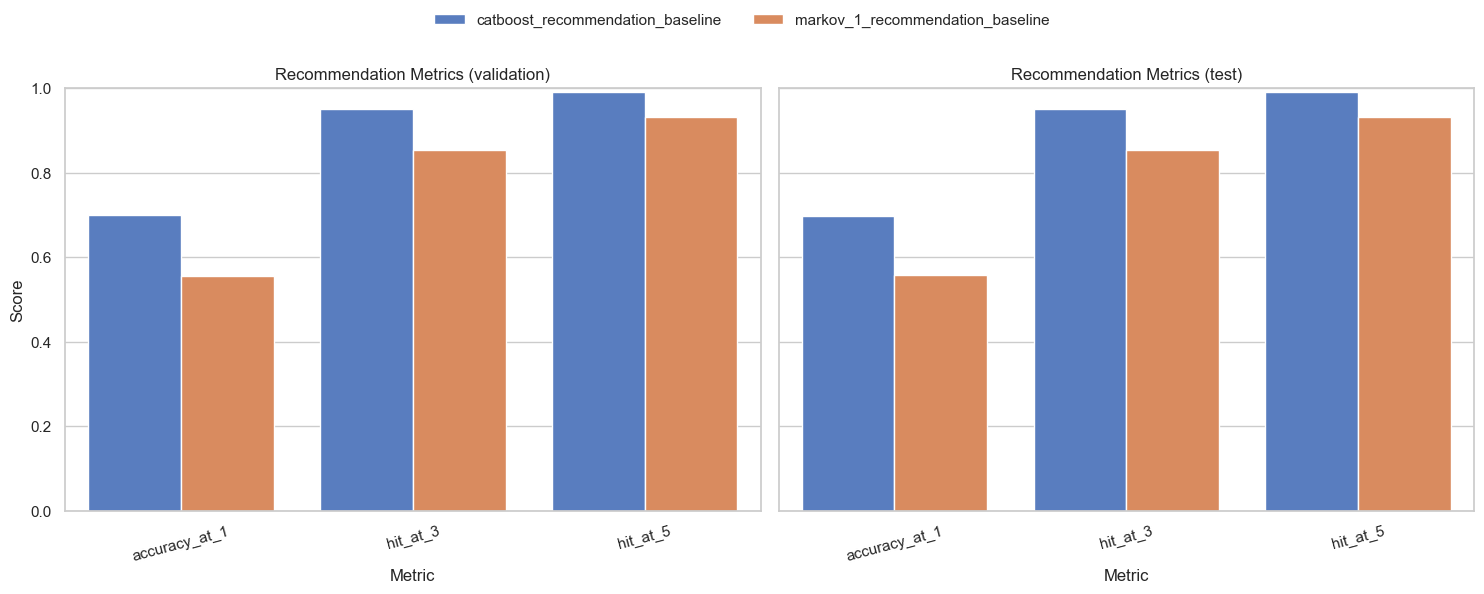

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\recommendation_catboost_vs_markov_grouped_metrics.png
Saved table: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\recommendation_hitk_curve.csv


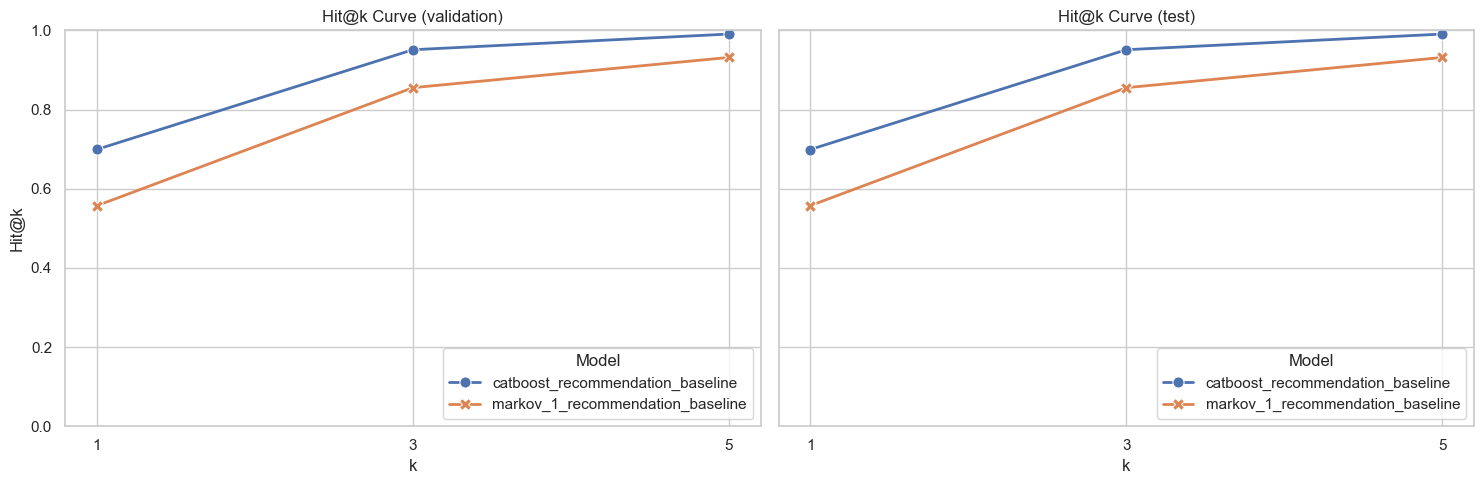

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\recommendation_catboost_vs_markov_hitk_curve.png


: 

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def load_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)


def save_figure(fig, out_path, dpi=300):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path)
    plt.close(fig)


recommendation_dir = RESULTS_DIR / "recommendation"
markov_dir = RESULTS_DIR / "markov_recommendation"
plot_dir = RESULTS_DIR / "recommendation"

catboost_metrics = load_csv_if_exists(recommendation_dir / "recommendation_metrics_baseline.csv")
markov_metrics = load_csv_if_exists(markov_dir / "overall_metrics.csv")
comparison_file = load_csv_if_exists(markov_dir / "comparison_with_catboost.csv")

if comparison_file is not None and not comparison_file.empty:
    metrics_df = comparison_file.copy()
else:
    pieces = []
    if isinstance(catboost_metrics, pd.DataFrame):
        pieces.append(catboost_metrics.copy())
    if isinstance(markov_metrics, pd.DataFrame):
        pieces.append(markov_metrics.copy())
    metrics_df = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

if metrics_df.empty:
    print("Recommendation comparison plot is skipped: no metrics artifact found.")
    print("Searched files:")
    print(" -", recommendation_dir / "recommendation_metrics_baseline.csv")
    print(" -", markov_dir / "overall_metrics.csv")
    print(" -", markov_dir / "comparison_with_catboost.csv")
else:
    metrics_df = metrics_df.copy()
    needed = ["model", "split", "accuracy_at_1", "hit_at_3", "hit_at_5"]
    missing = [c for c in needed if c not in metrics_df.columns]
    if missing:
        print("Metrics table is missing required columns:", missing)
    else:
        keep_models = ["catboost_recommendation_baseline", "markov_1_recommendation_baseline"]
        metrics_df = metrics_df[metrics_df["model"].isin(keep_models)].copy()

        if metrics_df.empty:
            print("No required models were found in metrics table.")
            print("Expected models:", keep_models)
        else:
            metrics_df["model"] = pd.Categorical(metrics_df["model"], categories=keep_models, ordered=True)
            metrics_df = metrics_df.sort_values(["split", "model"]).reset_index(drop=True)

            metrics_df.to_csv(plot_dir / "recommendation_model_comparison_metrics.csv", index=False)
            print("Saved table:", plot_dir / "recommendation_model_comparison_metrics.csv")

            # 1) Grouped bar chart by split and metric.
            melt_df = metrics_df.melt(
                id_vars=["model", "split"],
                value_vars=["accuracy_at_1", "hit_at_3", "hit_at_5"],
                var_name="metric",
                value_name="value",
            )

            fig1, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
            for i, split_name in enumerate(["validation", "test"]):
                sdf = melt_df[melt_df["split"] == split_name].copy()
                if sdf.empty:
                    axes[i].set_visible(False)
                    continue
                sns.barplot(data=sdf, x="metric", y="value", hue="model", ax=axes[i], palette="muted")
                axes[i].set_title(f"Recommendation Metrics ({split_name})")
                axes[i].set_xlabel("Metric")
                axes[i].set_ylabel("Score")
                axes[i].set_ylim(0, 1)
                axes[i].tick_params(axis="x", rotation=15)

            handles, labels = axes[0].get_legend_handles_labels()
            if handles:
                fig1.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
            for ax in axes:
                if ax.get_legend() is not None:
                    ax.get_legend().remove()
            fig1.tight_layout(rect=(0, 0, 1, 0.92))
            save_figure(fig1, plot_dir / "recommendation_catboost_vs_markov_grouped_metrics.png")

            # 2) Hit@k curve (k=1,3,5)
            curve_rows = []
            for _, row in metrics_df.iterrows():
                curve_rows.extend([
                    {"model": row["model"], "split": row["split"], "k": 1, "hit_k": float(row["accuracy_at_1"]), "metric": "accuracy_at_1"},
                    {"model": row["model"], "split": row["split"], "k": 3, "hit_k": float(row["hit_at_3"]), "metric": "hit_at_3"},
                    {"model": row["model"], "split": row["split"], "k": 5, "hit_k": float(row["hit_at_5"]), "metric": "hit_at_5"},
                ])
            hitk_curve_df = pd.DataFrame(curve_rows)
            hitk_curve_df.to_csv(plot_dir / "recommendation_hitk_curve.csv", index=False)
            print("Saved table:", plot_dir / "recommendation_hitk_curve.csv")

            fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
            for i, split_name in enumerate(["validation", "test"]):
                sdf = hitk_curve_df[hitk_curve_df["split"] == split_name].copy()
                if sdf.empty:
                    axes2[i].set_visible(False)
                    continue
                sns.lineplot(
                    data=sdf,
                    x="k",
                    y="hit_k",
                    hue="model",
                    style="model",
                    markers=True,
                    dashes=False,
                    linewidth=2,
                    markersize=8,
                    ax=axes2[i],
                )
                axes2[i].set_title(f"Hit@k Curve ({split_name})")
                axes2[i].set_xlabel("k")
                axes2[i].set_ylabel("Hit@k")
                axes2[i].set_xticks([1, 3, 5])
                axes2[i].set_ylim(0, 1)

            for ax in axes2:
                if ax.get_legend() is not None:
                    ax.legend(title="Model", loc="lower right")
            fig2.tight_layout()
            save_figure(fig2, plot_dir / "recommendation_catboost_vs_markov_hitk_curve.png")